In [1]:
import os
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from skimage.feature import local_binary_pattern

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    classification_report
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [ ]:
LABEL_NAMES = ["Normal", "Benign", "Malignant"]

def load_labels(path):
    """
    Load image labels from a text file

    Parameters
    ----------
    path : str
        Path to the label file

    Returns
    -------
    dict
        Dictionary mapping image filename to integer class label
    """
    labels = {}
    with open(path) as f:
        for line in f:
            img, lbl = line.strip().split(',')
            labels[img] = int(lbl)
    return labels

# Load ROI bounding boxes from the JSON file
with open("bbox_annot.json") as f:
    bbox_data = json.load(f)

In [ ]:
def extract_lbp_features(img_path, bbox):
    """
    Extract an LBP histogram feature vector from the ROI

    Parameters
    ----------
    img_path : str
        Path to the image file
    bbox : list[int]
        Bounding box coordinates in the form [x1, y1, x2, y2]

    Returns
    -------
    np.ndarray or None
        Normalised LBP histogram if successful, otherwise None
    """

    # Read the image in grayscale
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        return None

    # keep coordinates inside image boundaries
    x1, y1, x2, y2 = bbox
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(img.shape[1], x2), min(img.shape[0], y2)

    # Crop the roi
    roi = img[y1:y2, x1:x2]
    if roi.size == 0:
        return None

    # Resize roi so every image dimension is same
    roi = cv2.resize(roi, (128, 128))

    # LBP neighbourhood
    radius = 1
    n_points = 8 * radius

    # Compute the local binary pattern image
    lbp = local_binary_pattern(roi, n_points, radius, method='uniform')
    # Convert the LBP image into a histogram feature vector
    hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, n_points + 3), range=(0, n_points + 2))

    # Turn to a float and normalise values to sum to 1.
    hist = hist.astype("float")
    hist /= (hist.sum() + 1e-6)

    return hist

In [ ]:
# Lists to store the extracted feature vectors and labels
X, y = [], []

labels = load_labels("train.txt")

# Loop through labelled training images
for img_name, lbl in labels.items():
    if img_name not in bbox_data:
        continue

    img_path = f"imgs/{img_name}"
    if not os.path.exists(img_path):
        continue

    # Use the first bounding box for the image
    bbox = bbox_data[img_name]["bbs"][0][1]
    # Extract the LBP texture features from the roi
    features = extract_lbp_features(img_path, bbox)

    if features is None:
        continue

    # Store feature vector and its class label
    X.append(features)
    y.append(lbl)

# Convert lists into numpy arrays
X = np.array(X, dtype=np.float32)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1133, 10)
y shape: (1133,)


In [ ]:
# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# binarise test labels so ROC curves can be plotted
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

models = {
    "k-NN": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)),
    "SVM": make_pipeline(StandardScaler(), SVC(kernel="rbf", probability=True, random_state=42)),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}


k-NN
              precision    recall  f1-score   support

      Normal       0.69      0.74      0.72        80
      Benign       0.74      0.87      0.80       102
   Malignant       0.38      0.18      0.24        45

    accuracy                           0.69       227
   macro avg       0.60      0.60      0.59       227
weighted avg       0.65      0.69      0.66       227


SVM
              precision    recall  f1-score   support

      Normal       0.69      0.82      0.75        80
      Benign       0.73      0.94      0.82       102
   Malignant       0.00      0.00      0.00        45

    accuracy                           0.71       227
   macro avg       0.47      0.59      0.52       227
weighted avg       0.57      0.71      0.63       227


Decision Tree
              precision    recall  f1-score   support

      Normal       0.71      0.79      0.75        80
      Benign       0.73      0.91      0.81       102
   Malignant       0.20      0.04      0.07      

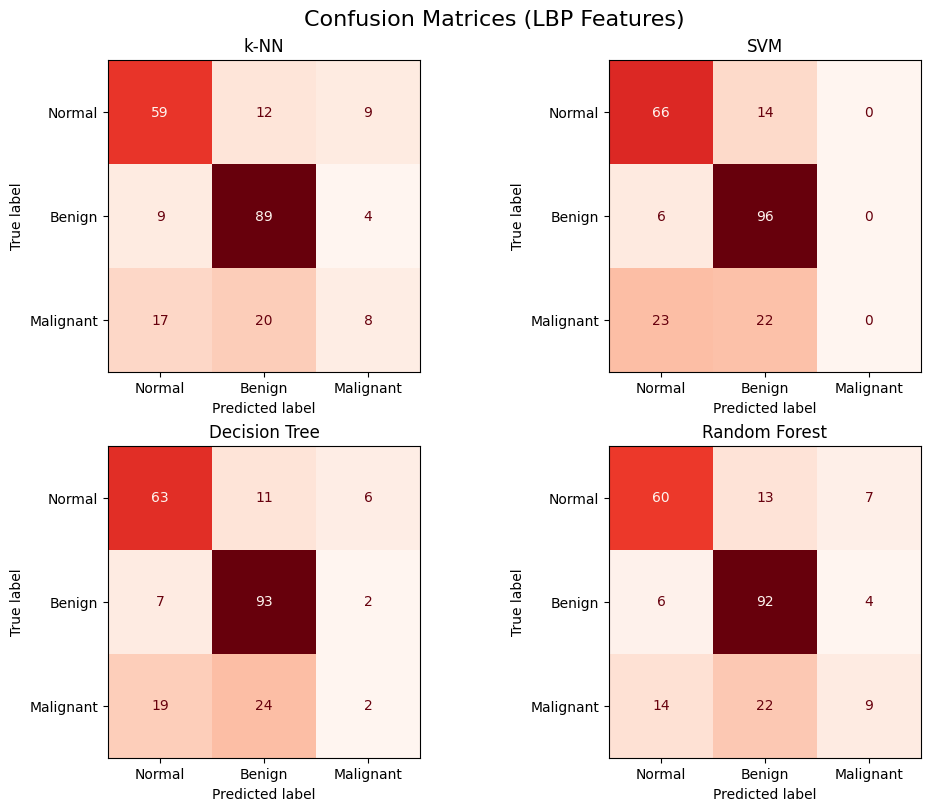

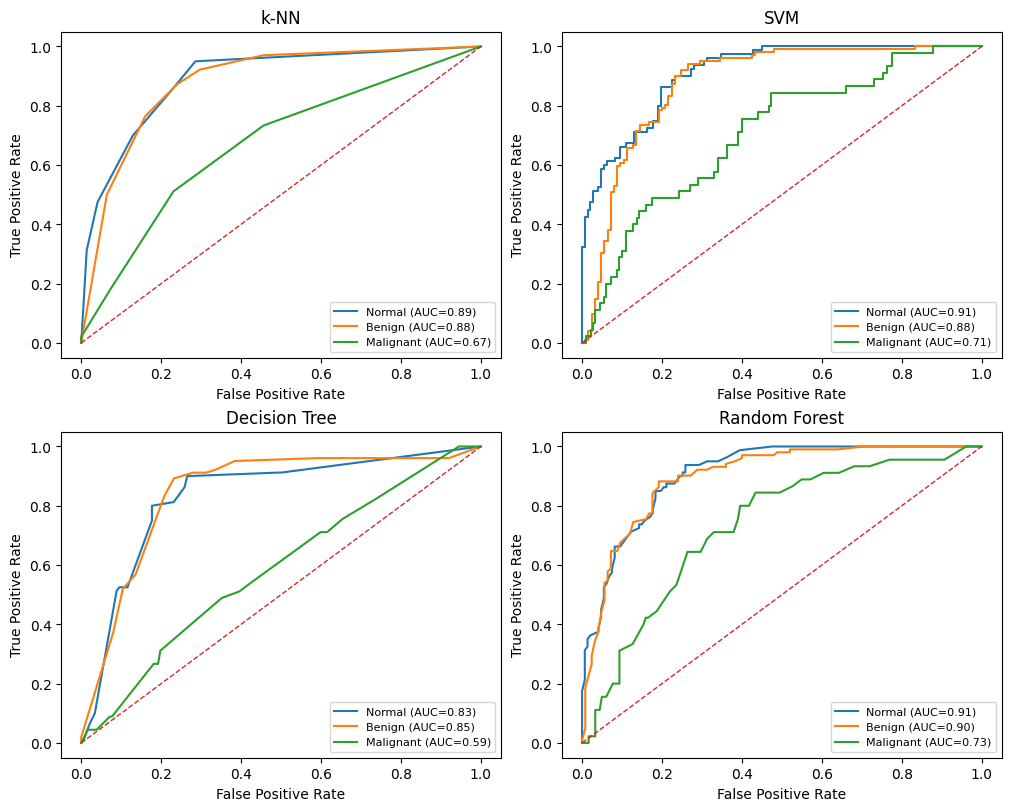

In [ ]:
# To store metrics for summary table
results = []

# Create  2x2 grids for the confusion matrices and ROC curves
fig_cm, axes_cm = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)
axes_cm = axes_cm.ravel()

fig_roc, axes_roc = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)
axes_roc = axes_roc.ravel()

# Train and evaluate each model
for i, (name, model) in enumerate(models.items()):
    model.fit(X_train, y_train)

    # Predict the class labels for the test set and probabilities for ROC curve
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)

    # Calculate the main performance metrics
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, average="macro", zero_division=0)
    rec = recall_score(y_test, preds, average="macro", zero_division=0)
    f1 = f1_score(y_test, preds, average="macro", zero_division=0)

    results.append([name, acc, prec, rec, f1])

    print(f"\n{name}")
    print(classification_report(y_test, preds, target_names=LABEL_NAMES, zero_division=0))

    # Build and plot the confusion matrix for current model
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABEL_NAMES)
    disp.plot(ax=axes_cm[i], cmap="Reds", colorbar=False)
    axes_cm[i].set_title(name)

    # For each class plot a one vs rest ROC curve for each class
    ax = axes_roc[i]
    for c in range(3):
        fpr, tpr, _ = roc_curve(y_test_bin[:, c], probs[:, c])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f"{LABEL_NAMES[c]} (AUC={roc_auc:.2f})")

    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
    ax.set_title(name)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(fontsize=8)

fig_cm.suptitle("Confusion Matrices (LBP Features)", fontsize=16)
plt.show()

fig_roc.suptitle("ROC Curves (LBP Features)", fontsize=16)
plt.show()

In [ ]:
# Results table
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"])
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,k-NN,0.687225,0.603536,0.595942,0.585261
1,SVM,0.713656,0.474003,0.588725,0.524933
2,Decision Tree,0.696035,0.544809,0.581236,0.542328
3,Random Forest,0.709251,0.641470,0.617320,0.610139
